In [1]:
import sys
print(sys.executable)

C:\Users\MSI\phishing-detector\venv\Scripts\python.exe


In [2]:
import pandas as pd
import sklearn

print("Pandas OK")
print("Scikit-learn OK")

Pandas OK
Scikit-learn OK


In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [4]:
import transformers
import datasets
import accelerate

print("transformers version:", transformers.__version__)
print("datasets imported successfully")
print("accelerate imported successfully")

transformers version: 5.5.4
datasets imported successfully
accelerate imported successfully


In [5]:
import pandas as pd

balanced_df = pd.read_csv(
    "data/processed/balanced_cleaned_emails.csv",
    encoding="latin1",
    usecols=["clean_text", "label"],
    nrows=10000,
    dtype={"clean_text": str}   # only force text, NOT label
)

# Clean label column safely
balanced_df["label"] = pd.to_numeric(balanced_df["label"], errors="coerce")

# Remove bad rows
balanced_df = balanced_df.dropna(subset=["clean_text", "label"])

# Convert label to int AFTER cleaning
balanced_df["label"] = balanced_df["label"].astype(int)

print("Dataset loaded:", balanced_df.shape)
print(balanced_df["label"].value_counts())

Dataset loaded: (7162, 2)
label
0      3592
1      3569
694       1
Name: count, dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_18284\2714529769.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  balanced_df = pd.read_csv(


In [6]:
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

## Step 9.1: Prepare Pilot Dataset

A smaller balanced subset of the cleaned dataset is created for the initial DistilBERT experiment.

This pilot dataset is used to validate the transformer training pipeline before scaling to a larger dataset. Using a smaller subset reduces computational cost and helps detect implementation issues early while preserving class balance between legitimate and phishing emails.

In [7]:
# Keep only required columns
bert_df = balanced_df[["clean_text", "label"]].copy()

# Create balanced pilot dataset manually
pilot_legit = bert_df[bert_df["label"] == 0].sample(n=2000, random_state=42)
pilot_phish = bert_df[bert_df["label"] == 1].sample(n=2000, random_state=42)

# Combine and shuffle
pilot_df = pd.concat([pilot_legit, pilot_phish]) \
              .sample(frac=1, random_state=42) \
              .reset_index(drop=True)

# Check dataset
print("Pilot dataset shape:", pilot_df.shape)
print("\nClass distribution:")
print(pilot_df["label"].value_counts())

Pilot dataset shape: (4000, 2)

Class distribution:
label
0    2000
1    2000
Name: count, dtype: int64


## Step 9.2: Train-Test Split for DistilBERT

The pilot dataset is split into training and testing subsets using stratified sampling. This ensures that both classes remain balanced across the split and allows the transformer model to be evaluated fairly on unseen data.

In [8]:
from sklearn.model_selection import train_test_split

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    pilot_df["clean_text"],
    pilot_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=pilot_df["label"]
)

print("Training samples:", len(X_train_bert))
print("Test samples:", len(X_test_bert))

print("\nTraining label distribution:")
print(y_train_bert.value_counts())

print("\nTest label distribution:")
print(y_test_bert.value_counts())

Training samples: 3200
Test samples: 800

Training label distribution:
label
1    1600
0    1600
Name: count, dtype: int64

Test label distribution:
label
1    400
0    400
Name: count, dtype: int64


## Step 9.3: Load DistilBERT Tokenizer

The DistilBERT tokenizer is loaded to convert email text into token IDs compatible with the pretrained transformer model.


In [9]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


## Step 9.4: Convert Data to Dataset Format

The training and testing splits are converted into Hugging Face Dataset objects. This format is required for efficient tokenization and training with the Trainer API.

In [10]:
from datasets import Dataset

train_df_bert = pd.DataFrame({
    "text": X_train_bert.tolist(),
    "label": y_train_bert.tolist()
})

test_df_bert = pd.DataFrame({
    "text": X_test_bert.tolist(),
    "label": y_test_bert.tolist()
})

train_dataset = Dataset.from_pandas(train_df_bert)
test_dataset = Dataset.from_pandas(test_df_bert)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 3200
})
Dataset({
    features: ['text', 'label'],
    num_rows: 800
})


## Step 9.5: Tokenize Email Text

The text is tokenized using the DistilBERT tokenizer. Padding and truncation are applied so that all inputs have a fixed maximum sequence length for model training.

In [11]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [12]:
if "text" in tokenized_train.column_names:
    tokenized_train = tokenized_train.remove_columns(["text"])

if "text" in tokenized_test.column_names:
    tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

print(tokenized_train)
print(tokenized_test)

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 3200
})
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 800
})


## Step 9.6: Load Pretrained DistilBERT Model

A pretrained DistilBERT model is loaded and configured for binary sequence classification. The classifier head is adapted to output two classes: legitimate and phishing.

Using a pretrained model allows the system to benefit from existing language knowledge while fine-tuning it on the phishing detection task.

In [13]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [14]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Model loaded successfully.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.


## Step 9.7: Define Evaluation Metrics

To ensure fair comparison with the baseline model, the DistilBERT classifier is evaluated using accuracy, precision, recall, and F1-score.

These metrics are especially important in phishing detection, where both false positives and false negatives have practical consequences.

In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )
    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## Step 9.8: Configure Training

A conservative training configuration is used for the initial DistilBERT experiment. This keeps the pilot run computationally manageable while still allowing meaningful evaluation of the transformer model.

The best model is selected based on F1-score, which is a suitable metric for phishing detection because it balances precision and recall.

In [17]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_distilbert",
    save_strategy="epoch",
    logging_strategy="no",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=False,
    fp16=torch.cuda.is_available(),
    report_to="none",
    disable_tqdm=True
)

## Step 9.9: Initialise Trainer

The Hugging Face Trainer API is used to manage training and evaluation. This helps keep the pipeline reproducible and reduces implementation complexity.

In [18]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)

print("Trainer initialised.")

Trainer initialised.


## Step 9.10: Train DistilBERT Pilot Model

The DistilBERT model is fine-tuned on the pilot phishing email dataset. This initial run is used to validate the full transformer pipeline before any larger-scale experiment is attempted.

In [19]:
trainer.train()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '33.05', 'train_samples_per_second': '193.6', 'train_steps_per_second': '24.2', 'train_loss': '0.1778', 'epoch': '2'}


TrainOutput(global_step=800, training_loss=0.17778432846069336, metrics={'train_runtime': 33.0515, 'train_samples_per_second': 193.637, 'train_steps_per_second': 24.205, 'train_loss': 0.17778432846069336, 'epoch': 2.0})

DistilBERT Evaluation
The trained DistilBERT model is evaluated on the held-out test set using the same metrics as the baseline model. This allows a fair comparison between the traditional machine learning approach and the transformer-based NLP approach.

In [20]:
eval_results = trainer.evaluate()
print(eval_results)

{'eval_loss': '0.2343', 'eval_accuracy': '0.9463', 'eval_precision': '0.9612', 'eval_recall': '0.93', 'eval_f1': '0.9454', 'eval_runtime': '0.9424', 'eval_samples_per_second': '848.9', 'eval_steps_per_second': '106.1', 'epoch': '2'}
{'eval_loss': 0.23430274426937103, 'eval_accuracy': 0.94625, 'eval_precision': 0.9612403100775194, 'eval_recall': 0.93, 'eval_f1': 0.9453621346886912, 'eval_runtime': 0.9424, 'eval_samples_per_second': 848.901, 'eval_steps_per_second': 106.113, 'epoch': 2.0}


In [21]:
pred_output = trainer.predict(tokenized_test)

y_pred_bert = np.argmax(pred_output.predictions, axis=1)
y_true_bert = np.array(y_test_bert)

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=["Legitimate", "Phishing"]
))

              precision    recall  f1-score   support

  Legitimate       0.93      0.96      0.95       400
    Phishing       0.96      0.93      0.95       400

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [23]:
cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
print(cm_bert)

[[385  15]
 [ 28 372]]


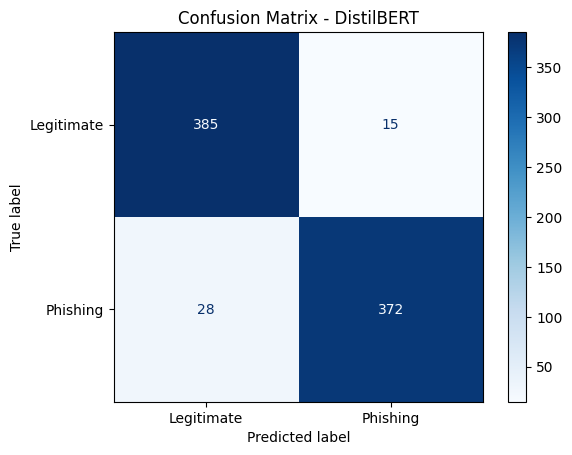

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - DistilBERT")
plt.show()

## Save DistilBERT Model

The fine-tuned DistilBERT model and tokenizer are saved for later reuse in testing, comparison, and deployment.

In [29]:
model.save_pretrained("saved_models/distilbert_phishing_model")
tokenizer.save_pretrained("saved_models/distilbert_phishing_model")

print("DistilBERT model and tokenizer saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model and tokenizer saved successfully.


## Model Comparison

The baseline Logistic Regression model and the DistilBERT model are compared using the same evaluation metrics. This comparison helps determine whether the additional complexity of the transformer model produces a meaningful improvement in phishing detection performance.

In [31]:
import pandas as pd

lr_accuracy = 0.9541
lr_precision = 0.9546
lr_recall = 0.9537
lr_f1 = 0.9541

bert_accuracy = 0.9462
bert_precision = 0.9612
bert_recall = 0.9300
bert_f1 = 0.9453

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "DistilBERT"],
    "Accuracy": [lr_accuracy, bert_accuracy],
    "Precision": [lr_precision, bert_precision],
    "Recall": [lr_recall, bert_recall],
    "F1-score": [lr_f1, bert_f1]
})

comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9541,0.9546,0.9537,0.9541
1,DistilBERT,0.9462,0.9612,0.9300,0.9453


### Final Model Comparison

The comparison between Logistic Regression and DistilBERT reveals that both models achieve strong and highly competitive performance on the phishing email classification task.

The Logistic Regression model achieved an accuracy of 0.9541 and an F1-score of 0.9541, slightly outperforming DistilBERT in overall balance. It also demonstrated consistently high precision (0.9546) and recall (0.9537), indicating stable performance across both legitimate and phishing classes.

DistilBERT achieved a slightly lower accuracy (0.9462) and F1-score (0.9453), but demonstrated higher precision (0.9612). This suggests that when DistilBERT predicts an email as phishing, it is more likely to be correct, reducing false positives. However, its lower recall (0.93) indicates that it misses more phishing emails compared to Logistic Regression.

This highlights a key trade-off: DistilBERT prioritises precision, while Logistic Regression provides a more balanced performance between precision and recall. In the context of phishing detection, recall is particularly important, as failing to detect phishing emails can have serious security implications.

Additionally, Logistic Regression is significantly more efficient, requiring less computational power and training time compared to DistilBERT. Despite the advanced contextual capabilities of transformer models, this experiment demonstrates that a well-tuned traditional machine learning model can remain highly competitive.

Overall, Logistic Regression appears to be the more practical choice for this task, given its slightly better performance and lower computational cost, while DistilBERT offers advantages in precision and contextual understanding.

In [32]:
model.save_pretrained("saved_models/distilbert_phishing_model")
tokenizer.save_pretrained("saved_models/distilbert_phishing_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('saved_models/distilbert_phishing_model\\tokenizer_config.json',
 'saved_models/distilbert_phishing_model\\tokenizer.json')

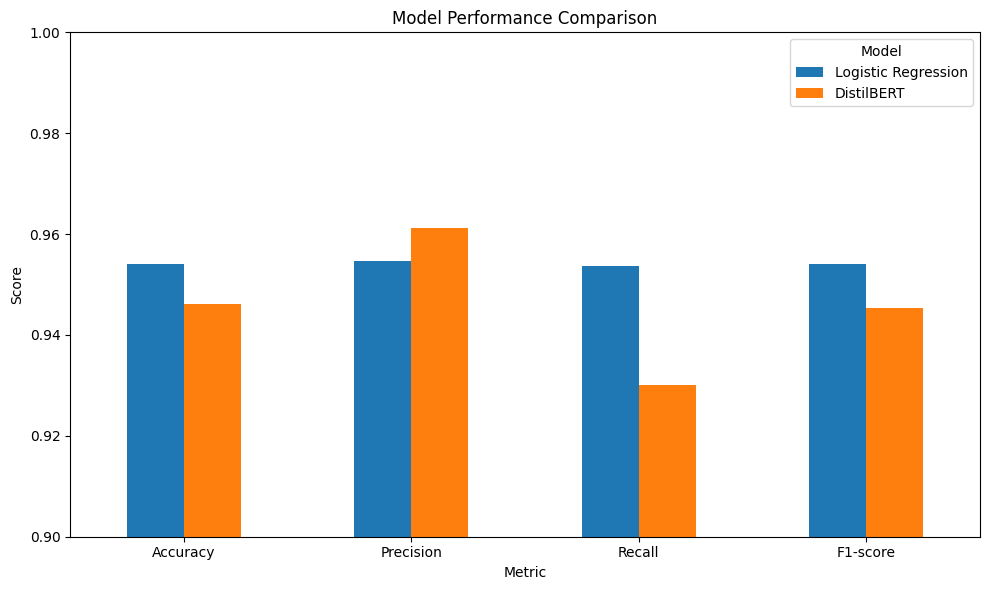

In [2]:
# Model results
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "DistilBERT"],
    "Accuracy": [0.9541, 0.9462],
    "Precision": [0.9546, 0.9612],
    "Recall": [0.9537, 0.9300],
    "F1-score": [0.9541, 0.9453]
})

# Set model names as index for plotting
plot_df = comparison_df.set_index("Model")

# Create bar chart
ax = plot_df.T.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")

plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.90, 1.00)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

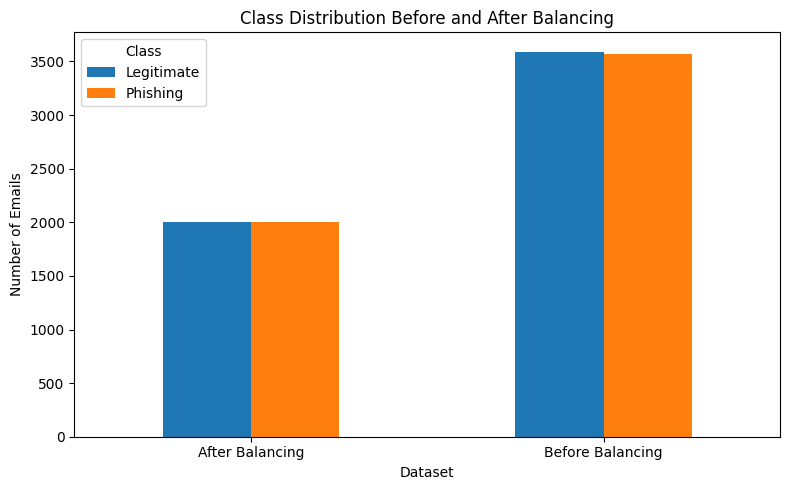

In [3]:
# Before and after balancing
class_dist_df = pd.DataFrame({
    "Dataset": ["Before Balancing", "Before Balancing", "After Balancing", "After Balancing"],
    "Class": ["Legitimate", "Phishing", "Legitimate", "Phishing"],
    "Count": [3592, 3569, 2000, 2000]
})

pivot_df = class_dist_df.pivot(index="Dataset", columns="Class", values="Count")

ax = pivot_df.plot(kind="bar", figsize=(8, 5))

plt.title("Class Distribution Before and After Balancing")
plt.ylabel("Number of Emails")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()